# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [2]:
%pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pytensor
pytensor.config.cxx = ""
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [4]:
# YOUR CODE HERE
# Group A: all Month-to-month contract rows
# Group B: all Two year contract rows
# Group A_small: 40 random rows from Group A, random_state=42
group_A       = df[df['Contract'] == 'Month-to-month']
group_B       = df[df['Contract'] == 'Two year']
group_A_small = group_A.sample(n=40, random_state=42)

k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!")


Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [5]:
alpha_prior, beta_prior = 2, 8   # Beta(2, 8) prior — do not change

# YOUR CODE HERE — for each group compute:
#   mle     = k / n
#   map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
#   pull    = |map_est - mle|  (how far prior pulls MAP from MLE)

groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}

print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle     = k/n   # YOUR CODE HERE
    map_est = (alpha_prior + k - 1)/(alpha_prior + beta_prior + n -2)   # YOUR CODE HERE
    pull    = abs(map_est - mle)   # YOUR CODE HERE
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")


Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


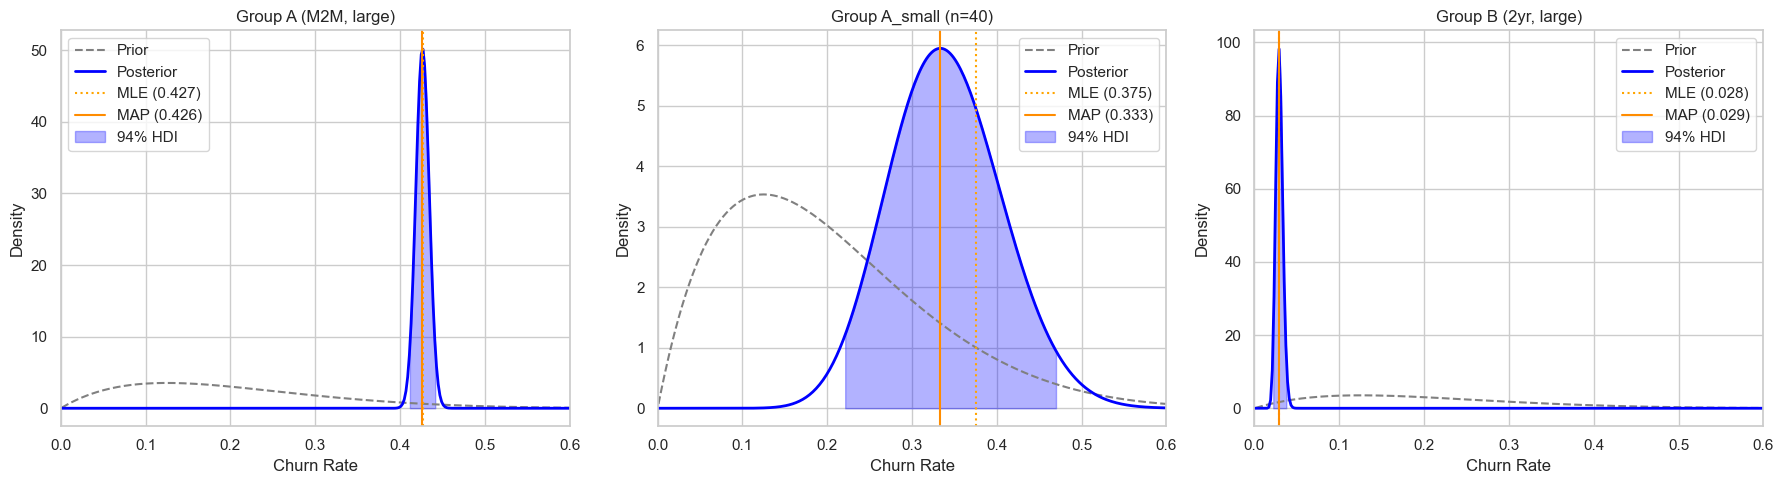

In [33]:
# YOUR CODE HERE — plot the three posterior PDFs on one figure
# For each group: plot Prior PDF, Posterior PDF, MLE and MAP as vertical lines
# Shade the 94% HDI as a fill_between
# Use scipy.stats.beta.pdf and scipy.stats.beta.ppf

theta_range = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k   
    beta_post  = beta_prior + (n - k)   

    prior_pdf = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    post_pdf = beta_dist.pdf(theta_range, alpha_post, beta_post)

    mle = k/n
    map_est = (alpha_post - 1)/(alpha_post + beta_post - 2)

    hdi_low = beta_dist.ppf(0.03, alpha_post, beta_post)
    hdi_high = beta_dist.ppf(0.97, alpha_post, beta_post)

    ax.plot(theta_range, prior_pdf, label='Prior', color='gray', linestyle='--')
    ax.plot(theta_range, post_pdf, label='Posterior', color='blue', lw = 2)
    ax.axvline(mle,color='orange', linestyle=':', label=f'MLE ({mle:.3f})')
    ax.axvline(map_est,color='darkorange', linestyle='-', label=f'MAP ({map_est:.3f})')
    
    hdi_range = np.linspace(hdi_low, hdi_high, 100)
    ax.fill_between(hdi_range, 0, beta_dist.pdf(hdi_range, alpha_post, beta_post), color='blue', alpha=0.3, label='94% HDI')

    ax.set_title(name)
    ax.set_xlabel('Churn Rate')
    ax.set_ylabel('Density')
    ax.set_xlim(0,0.6)
    ax.legend()
    
plt.tight_layout(); plt.show()


### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [7]:
MC_SAMPLES = 10_000
np.random.seed(42)

# YOUR CODE HERE
# Sample from both posteriors and compute P(θ_A > θ_B)
post_A_samples = np.random.beta(alpha_prior+k_A, beta_prior+n_A-k_A, MC_SAMPLES)
post_B_samples = np.random.beta(alpha_prior+k_B, beta_prior+n_B-k_B, MC_SAMPLES)
p_A_greater    = np.mean(post_A_samples > post_B_samples)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"P(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ We can tell the VP that Month-to-month churns at a higher rate with "
      f"{p_A_greater*100:.1f}% probability — without a p-value.")


P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability — without a p-value.


✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

1. What is the **prior pull** (|MAP − MLE|) for Group A_small vs Group B (large)?
   Why is it larger for the small group?
2. Which estimate would you present to the VP for Group A_small and why?
   What does each estimate provide that the others do not?
3. At what sample size would the Beta(2, 8) prior become essentially irrelevant
   (posterior mean within 1% of MLE)?

> *Your answer:*
1. The prior pull for Group A_small is 0.0417 and for Group B is 0.0005. It is larger for the small group because it has an extremely limited dataset (n=40), meaning the info content of the data likelihood is weak relative to the 10 pseudo-observations embedded in the Beta(2,8) prior.For group B (n>1000), the massive data likelihood completely overwhelms the prior, driving the prior pull close to zero.

2. For the small group, I would present the Full Bayesian distribution accompanied by its MAP point estimate. The MLE is overly reactive to data flukes in small samples, while MAP estimate provides a safe, prior-regularized baseline. The full bayesian framework provides a 94% HDI that visually communicates our severe parameter uncertainty to the vP, preventing overconfident decisions based on thin data.

3. Assuming the true empirical conversion rate aligns exactly with prior mean (20%), the sample size required for posterior mean to sit within 1% of the MLE depends on specific variance observed. For Beta(2,8) ie a prior representing 10 pseudo-observations, a sample size of n >= 1000 guarantees that the prior is essentially irrelevant.

---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [8]:
def update_posterior(alpha, beta, churn_label):
    if churn_label == 1:
        return alpha+1, beta
    
    else:
        return alpha, beta+1

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)   # churn event
a2, b2 = update_posterior(a0, b0, 0)   # non-churn event

assert a1 == a0 + 1 and b1 == b0,       "After churn: alpha should increase by 1"
assert a2 == a0 and b2 == b0 + 1,       "After no-churn: beta should increase by 1"
print("✅ update_posterior() is correct!")


✅ update_posterior() is correct!


### Q5 — Run sequential update and plot posterior evolution


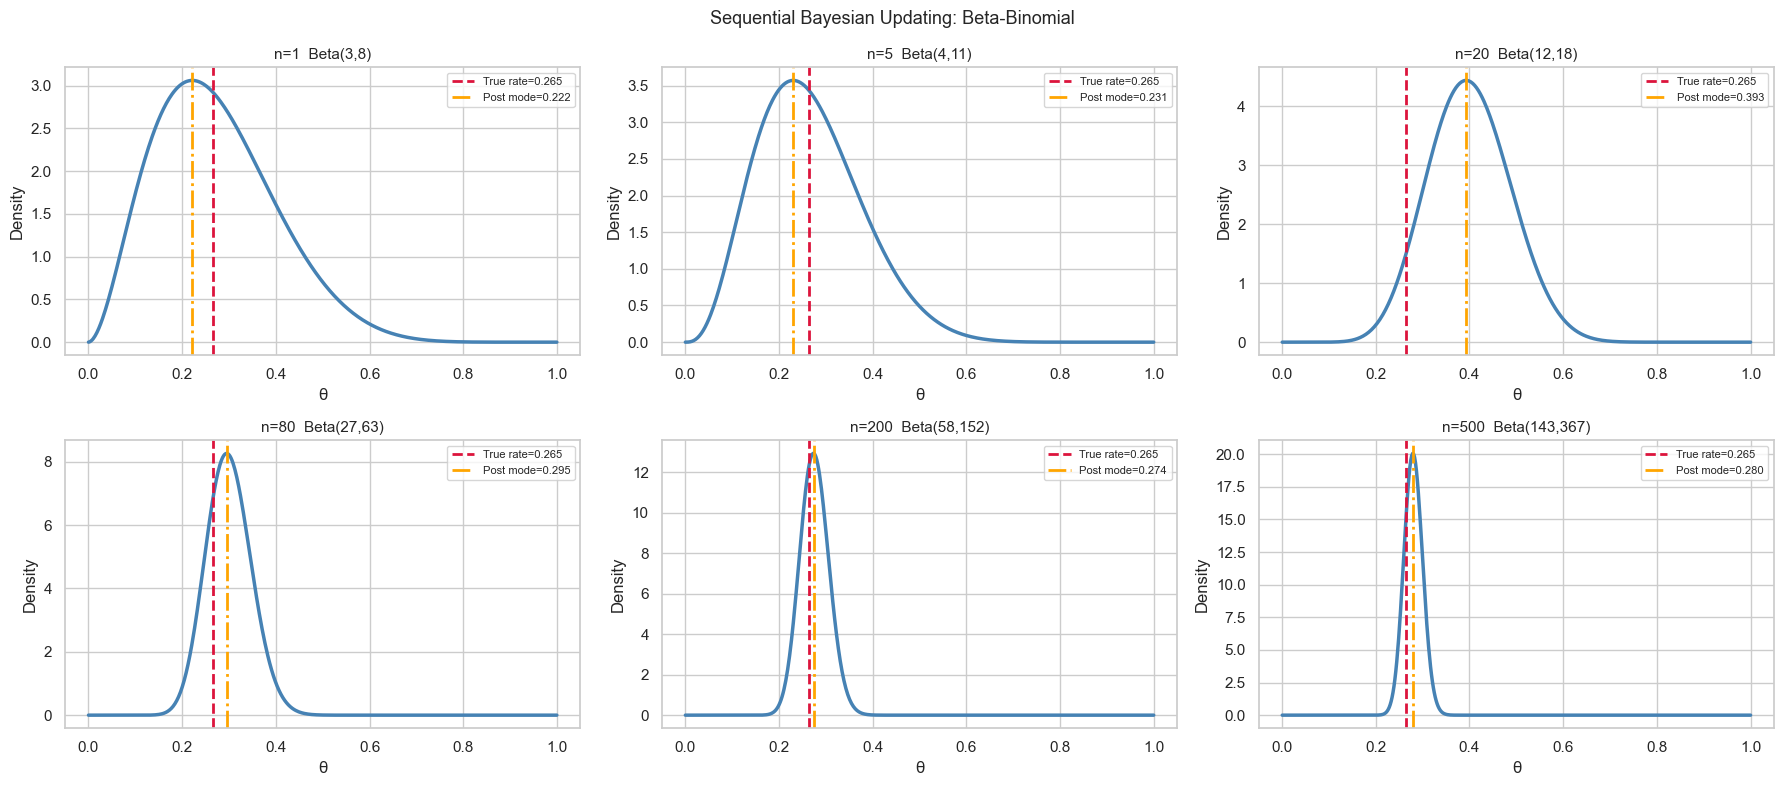

In [9]:
# Shuffle the Telco dataset (fixed seed)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE   = df['Churn'].mean()

snapshots   = [1, 5, 20, 80, 200, 500]

# YOUR CODE HERE:
# 1. Start with Beta(2, 8)
# 2. Run update_posterior on the first 500 rows of df_shuffled
# 3. Record (alpha, beta) at each snapshot n
# Store results as a dict: {n: (alpha_n, beta_n)}
alpha_init, beta_init = 2.0, 8.0
history = {}   # {n: (alpha_n, beta_n)}

current_alpha, current_beta = alpha_init, beta_init
for i in range(1, 501):
    label = df_shuffled.loc[i-1, 'Churn']
    current_alpha, current_beta = update_posterior(current_alpha, current_beta, label)
    if i in snapshots: 
        history[i] = (current_alpha, current_beta)

# Plot (runs after history is populated)
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.',  lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('θ'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()


### Q6 — Decision boundary: P(θ > 0.25) vs n


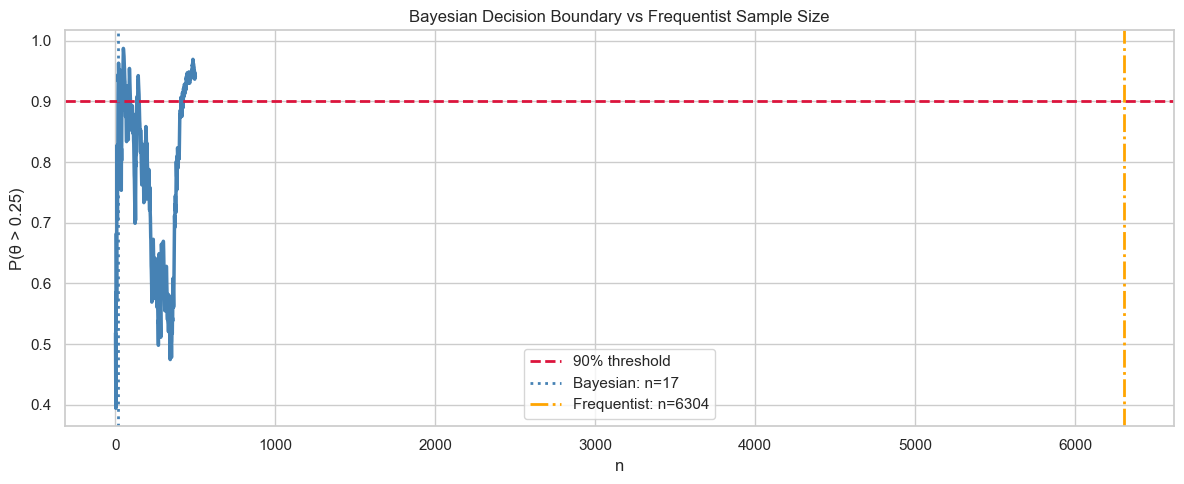

Bayesian: n = 17  |  Frequentist: n = 6304


In [10]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

# YOUR CODE HERE
# Run through the first 500 shuffled rows
# At each step, compute P(θ > threshold) by sampling 10,000 values from the current posterior
# Store as a list p_exceed (length 500)
p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0

for i in range(len(df_shuffled[:500])):
    label = df_shuffled.loc[i, 'Churn']
    alpha_seq, beta_seq = update_posterior(alpha_seq, beta_seq, label)
    samples = np.random.beta(alpha_seq, beta_seq, MC_SAMPLES)
    p_exceed.append(np.mean(samples > threshold))

# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1   = threshold, TRUE_RATE
freq_n   = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

# Find Bayesian threshold crossing
bayes_n  = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n'); ax.set_ylabel('P(θ > 0.25)'); ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")


### Q7 — Dirichlet-Multinomial: 3-category contract type


Posterior Dirichlet params: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]
MLE proportions: [0.55019168 0.20914383 0.24066449]
✅ Dirichlet posterior computed!


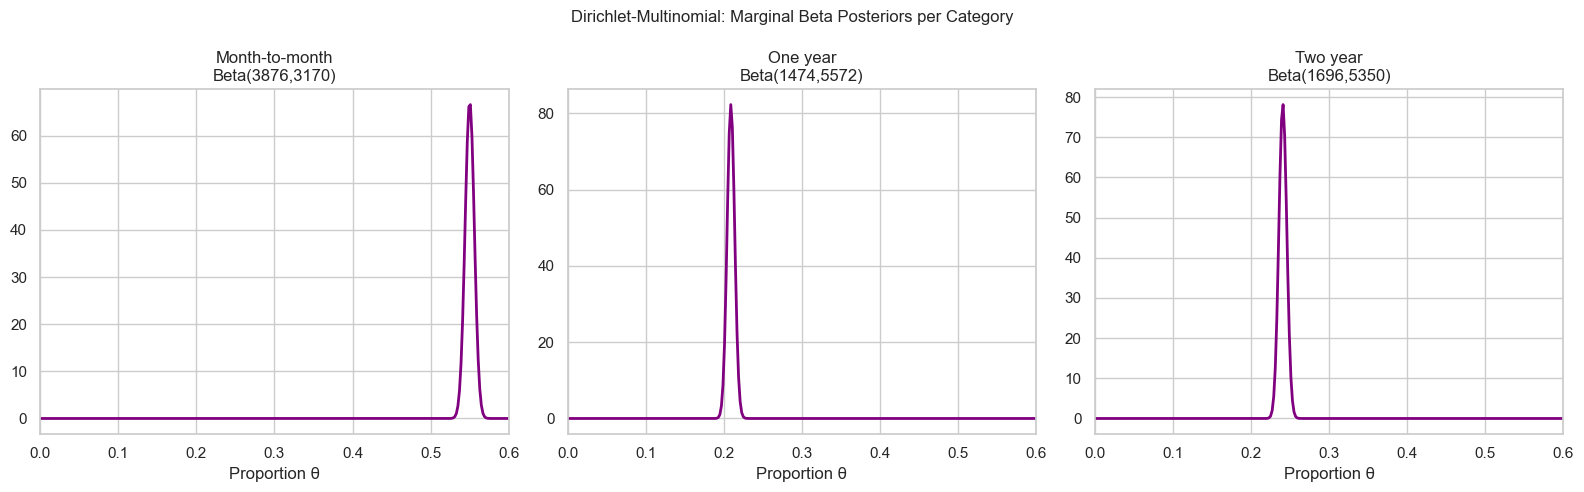

In [11]:
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])   # flat Dirichlet prior — do not change

# YOUR CODE HERE
# 1. Count observations for each contract category in the full dataset
# 2. Compute posterior Dirichlet parameters = prior + counts
# 3. Report posterior means for each category
counts           = np.array([df['Contract'].value_counts()[cat] for cat in categories])
posterior_alpha  = prior_alpha + counts

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")

# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    pdf = beta_dist.pdf(theta_r,a_j,b_j)
    ax.plot(theta_r, pdf, color='purple', lw=2)
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion θ')
    ax.set_xlim(0,0.6)

plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout(); plt.show()


In [12]:
# Unseen category: add "Biannual" with pseudocount = 1 (no observations)
# YOUR CODE HERE
# Show the marginal posterior for the new category
# Explain what this tells you about how Dirichlet handles unseen categories

new_alpha_4cat = np.append(posterior_alpha, 1.0)
biannual_mean = 1.0/new_alpha_4cat.sum()
m2m_mean = new_alpha_4cat[0]/new_alpha_4cat.sum()

print("Posterior for unseen 'Biannual' category:")
print(f"Binomial Posterior mean: {biannual_mean:.6f}")
print(f"Month-to-month posterior mean: {m2m_mean:.4f}")


Posterior for unseen 'Biannual' category:
Binomial Posterior mean: 0.000142
Month-to-month posterior mean: 0.5500


✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. Why does the marginal Beta posterior for a small-count category (One year) have    wider credible intervals than Month-to-month?
2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations,    what is its posterior equal to? What does this reveal about the Dirichlet prior?
3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent    of the Beta(2,8) prior's prior mean? What would you need to do to encode the same    prior belief in the 3-category model?

> *Your answer:*
1. The one year category has fewer observations, so the posterior distribution is more uncertain (less concentrated), which produces a wider credible interval, whereas the large Month-to-month sample provides more evidence and leads to a narrower credible interval.

2. The Dirichlet distribution handles unseen structural categories through its additive pseudocount framework. While a frequentist MLE model assigns an impossible 0% probability to an unseen category, the Dirichlet reserves a small probability space (~0.014%) for it based on the prior parameter. It allows the model to remain robust and open to new data.

3. Beta(2,8) has a prior mean of 0.2, meaning believing the success category has probability 0.2 before seeing data. To encode same belief in 3 category Dirichlet-Multinomial model, we need to switch from Beta to Dirichlet distribution while keeping the same prior strength. We assign 2 pseudo counts to the category we want to keep at 0.2 and then distribute the remaining 8 pseudo counts across other 2 categories. If no preference, even split ie Dirichlet(2,4,4). This preserves same prior idea,, one category has 20% mass, while remaining 80% is shared equally.

---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [13]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

# YOUR CODE HERE
# Compute the empirical mean vector and covariance matrix
# Report correlation ρ = Σ_12 / sqrt(Σ_11 * Σ_22)
mu_2d = np.mean(X_2d, axis=0)
Sigma_2d = np.cov(X_2d.T)
rho = Sigma_2d[0,1] / np.sqrt(Sigma_2d[0,0] * Sigma_2d[1,1])

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert mu_2d.shape    == (2,),    f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2),  f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1,              f"rho should be between -1 and 1, got {rho:.4f}"
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")


μ = [32.37 64.76]
Σ = 
[[603.17 183.2 ]
 [183.2  905.41]]
ρ = 0.2479
✅ 2D Gaussian fitted!


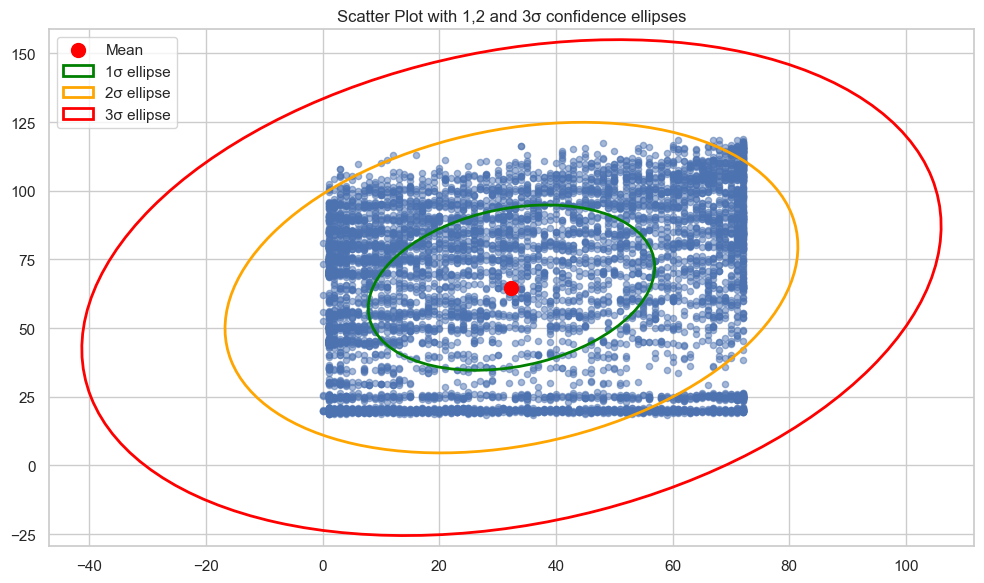

In [14]:
# YOUR CODE HERE — plot scatter + 1σ, 2σ, 3σ confidence ellipses
# Use the confidence_ellipse function pattern from the session notebook

def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v    = np.linalg.eigh(cov)
    angle   = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell     = Ellipse((0, 0),
                      width=2*n_std*np.sqrt(w[0]),
                      height=2*n_std*np.sqrt(w[1]),
                      angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(10, 6))
# YOUR CODE HERE: scatter plot with 1σ/2σ/3σ ellipses and mean marker
ax.scatter(X_2d[:,0],X_2d[:,1], s=20, alpha=0.5)
ax.scatter(mu_2d[0], mu_2d[1], color = 'red', s=100, label='Mean')
colors = ['green', 'orange', 'red']
for i, n in enumerate([1, 2, 3]):
    confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=n,
                       edgecolor=colors[i],
                       linewidth=2,
                       label=f'{n}σ ellipse')

ax.set_title("Scatter Plot with 1,2 and 3σ confidence ellipses")
ax.legend()
ax.grid(True)
plt.tight_layout(); plt.show()


### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [15]:
# YOUR CODE HERE — compute the conditional distribution P(MonthlyCharges | tenure = 24)
# Index convention: X_1 = MonthlyCharges (index 1 in X_2d), X_2 = tenure (index 0)
tenure_query = 24

# Extract scalar elements from Sigma_2d and mu_2d
mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # Σ_11
sig_t_t   = Sigma_2d[0, 0]    # Σ_22
sig_mc_t  = Sigma_2d[1, 0]    # Σ_12 = Σ_21

# YOUR CODE HERE: apply the conditional Gaussian formula
cond_mean = mu_mc + (sig_mc_t / sig_t_t) * (tenure_query - mu_t)
cond_var  = sig_mc_mc - (sig_mc_t / sig_t_t) * sig_mc_t
cond_std  = np.sqrt(cond_var)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")


Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]
  Empirical check:   $61.81  ← should be within ~$5
✅ Conditional Gaussian computed!


### Q10 — 3D Covariance and Condition Number


In [17]:
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)

# YOUR CODE HERE
# 1. Compute Sigma_3d = np.cov(X_3d.T)
# 2. Compute condition number kappa = np.linalg.cond(Sigma_3d)
# 3. Marginalise out TotalCharges by extracting the 2×2 upper-left block
# 4. Verify this matches Sigma_2d (should be identical)
Sigma_3d         = np.cov(X_3d.T)
eigenvalues = np.linalg.eigvals(Sigma_3d)
kappa            = np.max(eigenvalues) / np.min(eigenvalues)
Sigma_marginal   = Sigma_3d[:2, :2]   # upper-left 2×2 submatrix of Sigma_3d
max_diff         = np.max(np.abs(Sigma_2d - Sigma_marginal))  # max absolute difference vs Sigma_2d

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert max_diff < 1e-6, f"Marginalisation should match direct fit, got max diff={max_diff}"
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {max_diff:.2e}  ✅")


Condition number κ(Σ_3D) = 58988.9
Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = 0.00e+00  ✅


✍️ **Reflect 3 — Multivariate Gaussians:**

1. The condition number κ(Σ_3D) should be large (>> 100). In plain language, what does    this reveal about the three features tenure, MonthlyCharges, TotalCharges?
2. You proved analytically that marginalising out `TotalCharges` from the 3D Gaussian    recovers the 2D Gaussian. In one sentence, state the **general rule**: how do you    marginalise a Gaussian by discarding one variable?
3. Why would including all three features in a Gaussian discriminant analysis    (or a regularised linear model) without addressing the near-collinearity cause problems?    Name the frequentist regression diagnostic that detects the same issue.

> *Your answer:*
1. The large condition number (58988.9 >> 100) indicates that the three features are highly collinear. Specifically, totalchargers is approximately a deterministic product of tenure and monthlycharges. This creates data redundancy.

2. To marginalize a multivariate Gaussian distribution, we simply drop the unwanted variable rows and columns from the mean vector and covariance matrix.

3. Including all three collinear features in an unregularized model causes unstable, high-variance parameter estimates, as the inversion of an ill condition matrix amplifies the minor details or noise. The frequentist diagnostic tool designed to flag this issue is the Variance Inflation Factor(VIF).

---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [18]:
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()

df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

# YOUR CODE HERE — define the DAG structure as a list of (parent, child) tuples
# DAG: SeniorCitizen→Churn, Contract→Churn, tenure_disc→Churn,
#      InternetService→mc_disc, mc_disc→Churn
dag_edges = [
    ('SeniorCitizen', 'Churn'),
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc', 'Churn')
]

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")


✅ Bayesian Network fitted.
   Nodes: ['SeniorCitizen', 'Churn', 'Contract', 'tenure_disc', 'InternetService', 'mc_disc']
   Edges: [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('InternetService', 'mc_disc'), ('mc_disc', 'Churn')]


In [19]:
infer = VariableElimination(dag)

# YOUR CODE HERE — forward inference
# P(Churn | Contract = 'Month-to-month')
result_fwd = infer.query(variables=['Churn'], evidence={'Contract': 'Month-to-month'}, show_progress=False)
p_churn_m2m_bn = result_fwd.values[1]

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")


BN inference P(Churn=1 | Contract=M2M): 0.3542
Empirical:                              0.4271
Discrepancy: 0.0729

Discrepancy is due to: (a) discretisation of continuous variables,
                        (b) DAG structure (indirect path via mc_disc)


In [21]:
# YOUR CODE HERE — backward inference (explaining away)
# P(Contract | Churn = '1') — what does Bayesian inversion tell us?
result_bwd = infer.query(variables=['Contract'], evidence={'Churn': '1'}, show_progress=False)
print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This tells us: given a customer has churned, what is the probability they")
print("  were on each contract type? This is the INVERSE of the forward prediction.")


Backward inference P(Contract | Churn = 1):
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8017 |
+--------------------------+-----------------+
| Contract(One year)       |          0.1118 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0865 |
+--------------------------+-----------------+

Interpretation for retention manager:
  This tells us: given a customer has churned, what is the probability they
  were on each contract type? This is the INVERSE of the forward prediction.


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──────────────────────────────────→ Churn
tenure ─────────────────────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
SeniorCitizen ------------------> Churn
Contract --------> tenure --------> Churn
Contract ------------------------> Churn
InternetService ------> MonthlyCharges ----> Churn
```

**Observation set E where both models agree:** *(YOUR ANSWER)*

E = {Contract, tenure, SeniorCitizen, InternetService, MonthlyCharges}

**Observation set E where models disagree:** *(YOUR ANSWER)*

E = {Contract}

**Which causal story is more consistent with W5 SHAP findings?** *(YOUR ANSWER)*

The W5 SHAP results indicate that, tenure was one of the strongest drivers of churn, that supports a direct contribution of tenure to churn not a relation mediated by contract. so DAG1 is more consistent with the findings.

### Q13 — Markov Random Field: undirected model


In [24]:
# YOUR CODE HERE
# Build a DiscreteMarkovNetwork with the same 4 variables (undirected edges)
# Define pairwise DiscreteFactor objects from joint empirical frequencies
# Run BeliefPropagation to compute P(Churn)
# Compare to the BN's P(Churn) and the empirical base rate
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# Define undirected edges (same variables, no direction)
mrf_edges = [ ('SeniorCitizen', 'Churn'),
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc', 'Churn')]
mrf       = DiscreteMarkovNetwork(mrf_edges)   # DiscreteMarkovNetwork(mrf_edges)

for edge in mrf_edges:
    v1, v2 = edge
    joint_counts = pd.crosstab(df_pgm[v1], df_pgm[v2])
    factor = DiscreteFactor(
        variables=[v1,v2],
        cardinality=[df_pgm[v1].nunique(), df_pgm[v2].nunique()],
        values=joint_counts.values.flatten()
    )
    mrf.add_factors(factor)
    
bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn']).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")


MRF P(Churn): +----------+--------------+
| Churn    |   phi(Churn) |
+==========+==============+
| Churn(0) |       0.9833 |
+----------+--------------+
| Churn(1) |       0.0167 |
+----------+--------------+
BN  P(Churn=1): 0.2431
Empirical:      0.2654


✍️ **Reflect 4 — PGMs:**

1. The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN    differs from the raw empirical proportion. Name the **two specific reasons** for    this discrepancy.
2. Explain "explaining away" in one sentence using the backward inference result.
3. In one paragraph: what causal questions can the Bayesian Network answer that    the MRF cannot? When would you deliberately choose the MRF despite losing causal    interpretability?

> *Your answer:*
1. The discrepancy between the BN forward inference and the raw empirical rate is due to:
- Information loss from continuous feature binning.
- The structural factorization constraints of the DAG, which forces paths to pass through intermediatory links rather than direct conditional probability.

2. Explaining away is an inference pattern where two independent causes compete to explain an observed event. In this network, if a customer has churned discovering they have a m2m contract provides a strong explanation for the churn, which lowers ('explains away') the suspected influence of high monthly charges.

3. A BN can answer interventional questions, support counterfactuals, and decompose effects along directed paths, none of which an MRF can do because its edges carry no causal direction. We would still choose the MRF when causal order is genuinely unknown or contested, when the graph was learned purely from observational data and orienting edges would be arbitrary, or when we need a symmetric model for tasks like imputation or anomaly detection where no variable is a privileged outcome.

---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [27]:
# YOUR CODE HERE — load in exactly these 3 lines
# from statsmodels.datasets import co2
# df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
# t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25

from statsmodels.datasets import co2
df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()

t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y = df_co2['co2'].values 

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")


✅ Mauna Loa loaded: 521 observations, 0.0–43.8 years
   CO₂ range: 313.4–373.8 ppm


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?

Ans: A combination of a steady, long-term upward trend and a sharp, annual cyclical oscillation.

- What kernel captures the slow upward trend?

DotProduct (with sigma_0=0 fixed). CO₂ rises nearly linearly. DotProduct gives k(x,x')=x·x', which extrapolates linearly beyond the training range. RBF would revert to the training mean outside the data, causing large test errors.

- What kernel captures the sharp annual cycle?

ExpSineSquared (Periodic). This kernel is explicitly designed to model repeating periodic functions; setting its periodicity strictly to 1.0 captures the repeating 1-year seasonal cycle.

- What kernel captures measurement noise?

WhiteKernel. This accounts for random, independent, identically distributed i.i.d. measurement errors and localized weather noise, preventing the GP model from overfitting to individual noisy points.


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | Slow, non-linear rise in baseline CO₂ over decades, accelerating, not purely linear | DotProduct | CO₂ rises nearly linear. DotProduct(sigma_0=0, sigma_0_bounds='fixed') gives k(x,x')=x·x', which extrapolates linearly by construction rather than reverting to the training mean |
| Seasonal | Near-perfect 12-month cycle driven by Northern Hemisphere vegetation | ExpSineSquared | Exact periodicity with fixed periodicity=1.0 (1 year); amplitude can vary slowly over time |
| Noise | Short-term residuals, instrument noise, weather, irregular fluctuations | WhiteKernel | WhiteKernel mops up i.i.d. observation noise |

> *Fill in the table above before writing any code.*


In [28]:
# Train/test split: train on indices 0–431 (1958–1993), test on 432+ (1994–2001)
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

# YOUR CODE HERE — construct the composite kernel
# k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
#   Hint: CO₂ rises ~1.5 ppm/yr — nearly linear. DotProduct gives k(x,x')=x·x'
#   which extrapolates linearly by construction. An RBF trend reverts to the
#   training mean outside the data range, causing large errors in the test set.
# k_seasonal = RBF(...) * ExpSineSquared(..., periodicity=1.0, periodicity_bounds='fixed')
# k_noise    = WhiteKernel(...)
# kernel     = k_trend + k_seasonal + k_noise
k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
k_seasonal = RBF(length_scale=5.0, length_scale_bounds=(1.0, 20.0)) \
           * ExpSineSquared(length_scale=1.0, periodicity=1.0,
                            periodicity_bounds='fixed',
                            length_scale_bounds=(0.5, 5.0))
k_noise    = WhiteKernel(noise_level=0.5, noise_level_bounds=(1e-3, 10.0))
kernel     = k_trend + k_seasonal + k_noise

# Fit the GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                               normalize_y=True, random_state=42)
gp.fit(t_train, y_train)

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")


Optimised kernel:
DotProduct(sigma_0=0) + RBF(length_scale=6.85) * ExpSineSquared(length_scale=4.73, periodicity=1) + WhiteKernel(noise_level=0.001)

✅ Test RMSE: 2.467 ppm


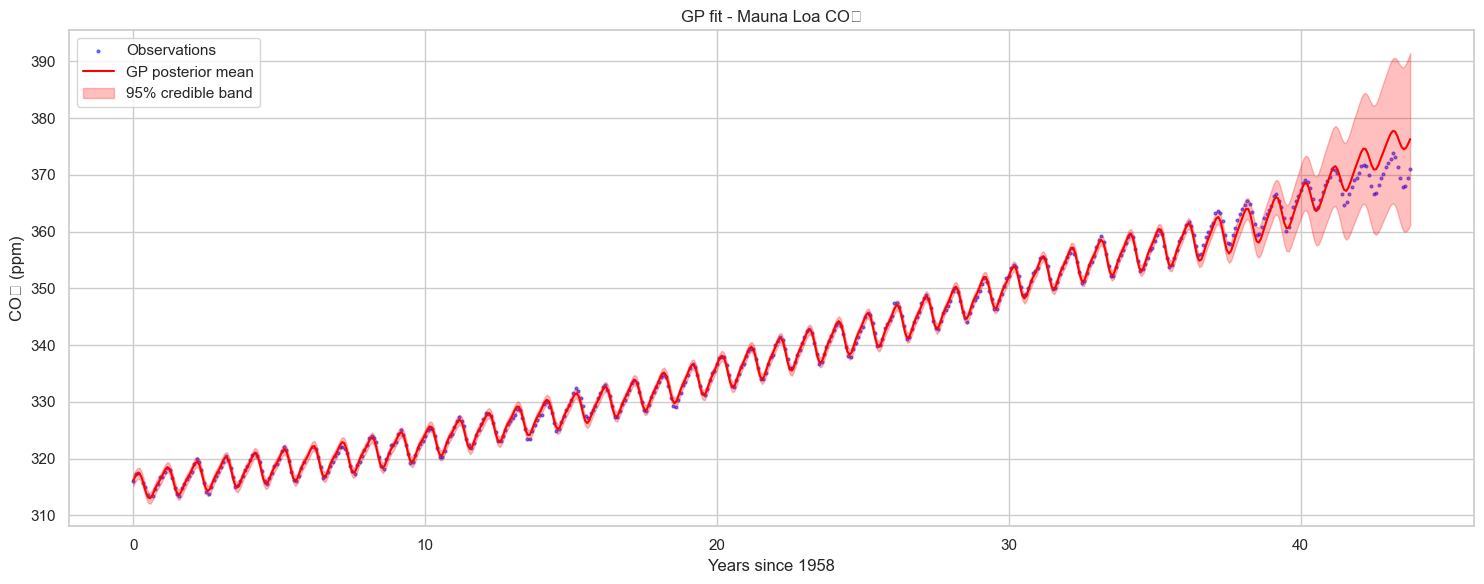

In [29]:
# YOUR CODE HERE — plot posterior mean and 95% credible bands
# Use gp.predict(t_full, return_std=True) where t_full covers the full training range
# Shade fill_between(mean - 2*std, mean + 2*std) for the 95% band

t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)

fig, ax = plt.subplots(figsize=(15, 6))
ax.scatter(t, y, s=4, color='blue', alpha=0.5, label='Observations')
ax.plot(t_full, y_pred, color='red', lw=1.5, label='GP posterior mean')
ax.fill_between(t_full.flatten(),
                y_pred - 2*y_std,
                y_pred + 2*y_std,
                alpha=0.25, color='red', label='95% credible band')
ax.set_xlabel('Years since 1958');
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('GP fit - Mauna Loa CO₂');
ax.legend()
plt.tight_layout(); plt.show()


### Q16 — Gap experiment


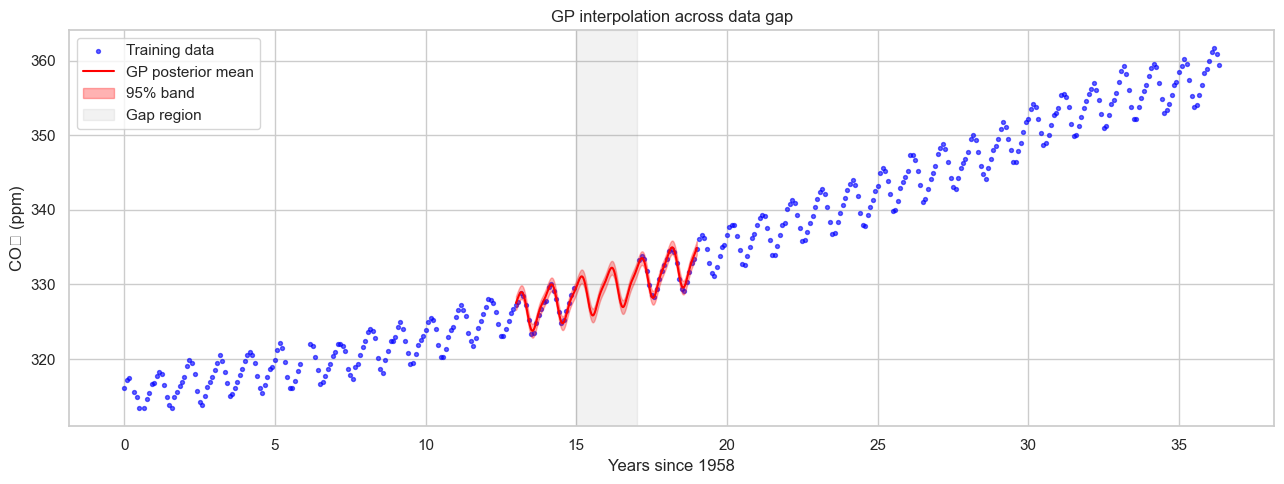

95% band width inside gap:   1.851 ppm
95% band width outside gap:  1.838 ppm
Gap inflation: 1.01×


In [31]:
# YOUR CODE HERE
# Remove all training observations between year 15 and year 17 (~1973–1975)
# Refit the GP on the remaining training data
# Zoom into the gap region and describe how the bands behave inside vs outside the gap

gap_lo, gap_hi = 15.0, 17.0

gap_mask = (t_train.flatten() < gap_lo) | (t_train.flatten() > gap_hi)
t_gap_tr = t_train[gap_mask]
y_gap_tr = y_train[gap_mask]

gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   normalize_y=True, random_state=42)

gp_gap.fit(t_gap_tr, y_gap_tr)

# Predict around the gap and plot
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(t_gap_tr, y_gap_tr, s=8, color='blue', alpha=0.6, label='Training data')
ax.plot(t_zoom, y_gz, color='red', lw=1.5, label='GP posterior mean')
ax.fill_between(t_zoom.flatten(),
                y_gz - 2*y_gz_std, y_gz + 2*y_gz_std,
                alpha=0.3, color='red', label='95% band')
ax.axvspan(gap_lo, gap_hi, alpha=0.1, color='gray', label='Gap region')
ax.set_xlabel('Years since 1958');
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('GP interpolation across data gap');
ax.legend()
plt.tight_layout(); plt.show()

# Compute band width inside vs outside gap
band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")


### Q17 — Extrapolation and the model confidence boundary


+ 5 yrs  band width: 15.011 ppm
+10 yrs  band width: 46.940 ppm
+15 yrs  band width: 72.077 ppm
Model confidence boundary: +2.2 years beyond training


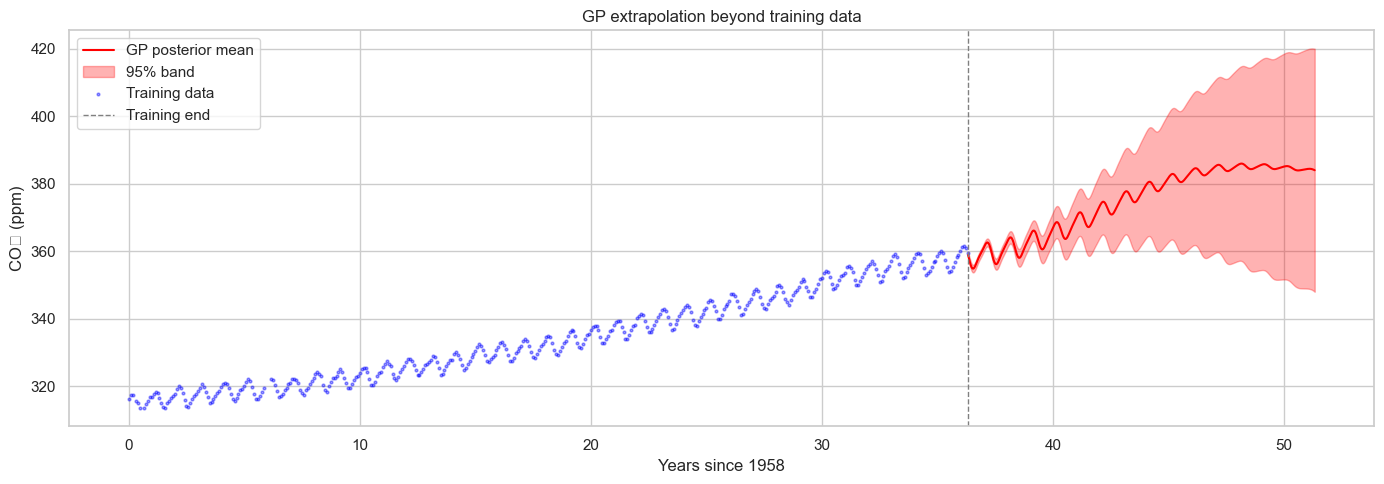

In [32]:
# YOUR CODE HERE
# 1. Predict 15 years beyond the last training point
# 2. Compute the 95% band width at 5, 10, 15 years of extrapolation
# 3. Find the horizon at which the band width first exceeds 5 ppm
# 4. Plot posterior mean + 95% bands for the extrapolation region

t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

# YOUR CODE HERE: compute band widths at +5, +10, +15 years
for years in [5, 10, 15]:
    idx = np.argmin(np.abs(t_extrap.flatten() - (t_last + years)))
    bw  = 4 * y_ex_std[idx]
    print(f"+{years:2d} yrs  band width: {bw:.3f} ppm")

# Find model confidence boundary (where 95% band > 5 ppm)
band_widths    = 4 * y_ex_std
exceed_5ppm    = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"Model confidence boundary: +{t_boundary:.1f} years beyond training")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_extrap, y_ex, color='red', lw=1.5, label='GP posterior mean')
ax.fill_between(t_extrap.flatten(),
                y_ex - 2*y_ex_std, y_ex + 2*y_ex_std,
                alpha=0.3, color='red', label='95% band')
ax.scatter(t_train, y_train, s=4, color='blue', alpha=0.4, label='Training data')
ax.axvline(t_last, color='gray', linestyle='--', lw=1, label='Training end')
ax.set_xlabel('Years since 1958');
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('GP extrapolation beyond training data');
ax.legend()
plt.tight_layout(); plt.show()


✍️ **Reflect 5 — Gaussian Processes:**

Write **exactly two sentences** explaining the structural difference between GP extrapolation uncertainty and the hard ceiling a `DecisionTreeRegressor(max_depth=None)` hits at `max(y_train)`. Connect to the W5 Assignment finding about tree extrapolation.

> *Your two sentences:*

A Gaussian Process explicitly models uncertainty that grows with extrapolation distance, allowing the posterior mean to extrapolate linearly (via the DotProduct kernel) while credible bands expand to reflect our ignorance—a theoretically principled approach to out-of-distribution prediction. In contrast, a DecisionTreeRegressor hits a hard ceiling at max(y_train) because leaf predictions are fixed training values that cannot be exceeded, replicating the dangerous asymptotic behavior you observed in W5 where trees flatline beyond the training range, offering no honest admission of uncertainty.

---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [34]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


Feature matrix: (5634, 5)
Features: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'InternetService_DSL', 'SeniorCitizen']


**✍️ Answer before running MCMC:**

Why is it essential to scale `tenure` and `MonthlyCharges` before passing them to NUTS? What happens to the posterior geometry if you don't scale? (Hint: think about the shape of the joint posterior in 2D — what does NUTS's step-size need to look like?)

> *Your answer (2-3 sentences):*

Unscaled features create an elongated posterior where the step-size must be tiny to navigate one direction but wastes computation in the other, leading to inefficient sampling or divergences. Scaling both features to zero mean and unit variance produces an isotropic posterior with uniform curvature, allowing NUTS to find a single step-size that efficiently explores the entire parameter space.

In [47]:
import time
n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    # YOUR CODE HERE
    # intercept: Normal(0, 5)
    # beta:      Normal(0, 2), shape=n_features
    # mu:        sigmoid(intercept + dot(X_tr_scaled, beta))
    # y_obs:     Bernoulli(p=mu, observed=y_tr_mc)
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    beta      = pm.Normal('beta', mu=0, sigma=2, shape=n_features)
    
    mu    = pm.Deterministic('mu', pm.math.sigmoid(
        intercept + pm.math.dot(X_tr_scaled, beta)))
    y_obs = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)

    # YOUR CODE HERE: sample with draws=2000, tune=1000, chains=4, target_accept=0.90
    idata = pm.sample(draws=2000, tune=1000, chains=4,
                      target_accept=0.90, random_seed=42,
                      return_inferencedata=True, progressbar=True)

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 39 seconds.


Sampling time: 56.4s
            mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
intercept -2.252  0.092    -2.404    -2.106  5267.011  4984.610  1.001   
beta[0]   -0.919  0.056    -1.009    -0.831  5941.630  5605.453  1.001   
beta[1]    0.820  0.050     0.741     0.900  5616.395  5211.774  1.000   
beta[2]    1.293  0.107     1.123     1.464  5305.884  5074.838  1.000   
beta[3]   -0.180  0.083    -0.313    -0.047  6428.300  5983.668  1.001   
beta[4]    0.417  0.091     0.270     0.561  7238.576  5043.400  1.001   

           mcse_mean  mcse_sd  
intercept      0.001    0.001  
beta[0]        0.001    0.000  
beta[1]        0.001    0.000  
beta[2]        0.001    0.001  
beta[3]        0.001    0.001  
beta[4]        0.001    0.001  


### Q19 — Convergence diagnostics


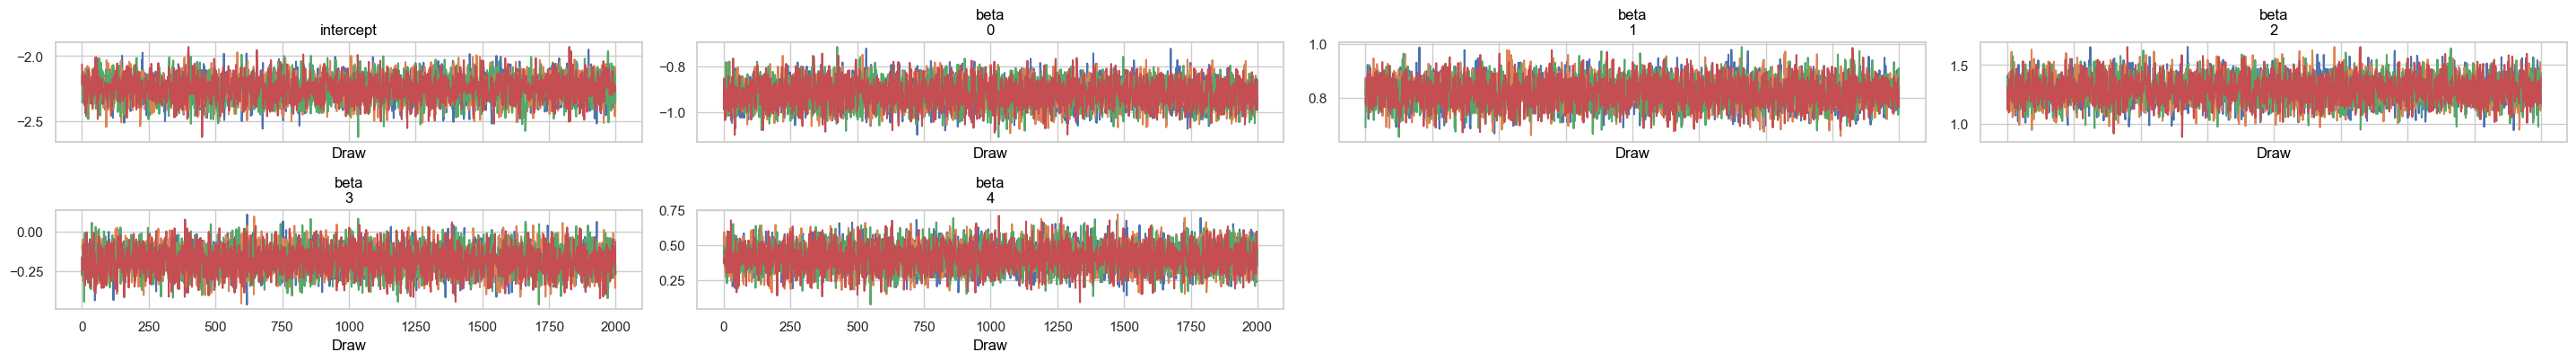

            mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
intercept -2.252  0.092    -2.404    -2.106  5267.011  4984.610  1.001   
beta[0]   -0.919  0.056    -1.009    -0.831  5941.630  5605.453  1.001   
beta[1]    0.820  0.050     0.741     0.900  5616.395  5211.774  1.000   
beta[2]    1.293  0.107     1.123     1.464  5305.884  5074.838  1.000   
beta[3]   -0.180  0.083    -0.313    -0.047  6428.300  5983.668  1.001   
beta[4]    0.417  0.091     0.270     0.561  7238.576  5043.400  1.001   

           mcse_mean  mcse_sd  
intercept      0.001    0.001  
beta[0]        0.001    0.000  
beta[1]        0.001    0.000  
beta[2]        0.001    0.001  
beta[3]        0.001    0.001  
beta[4]        0.001    0.001  

Flagged parameters (R̂ > 1.01 or ESS < 400):
None — all chains converged well


In [48]:
# YOUR CODE HERE
# 1. Plot trace plots with az.plot_trace() for intercept and beta
# 2. Report R̂ and bulk-ESS for each coefficient
# 3. Flag parameters with R̂ > 1.01 or bulk-ESS < 400
# 4. Describe whether the trace looks like a "fuzzy caterpillar" (good) or drifts (bad)

az.plot_trace(idata, var_names=['intercept', 'beta'])
plt.tight_layout(); plt.show()

summary = az.summary(idata, var_names=['intercept', 'beta'], round_to=3)
print(summary)

flagged = summary[(summary['r_hat'] > 1.01) | (summary['ess_bulk'] < 400)]
print("\nFlagged parameters (R̂ > 1.01 or ESS < 400):")
print(flagged if len(flagged) > 0 else "None — all chains converged well")


### Q20 — Prior sensitivity check


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 14 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


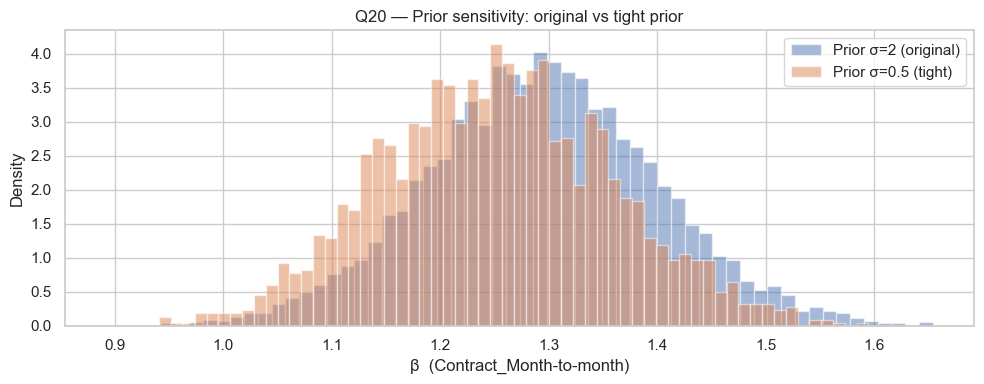

In [49]:
# YOUR CODE HERE
# 1. Refit the model with a tighter prior Normal(0, 0.5) on beta
# 2. Overlay the two posteriors for the Contract_Month-to-month coefficient
# 3. Decide: are the posteriors prior-robust or does the prior dominate?

contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

with pm.Model() as bayes_lr_tight:
    intercept_t = pm.Normal('intercept', mu=0, sigma=5)
    beta_t      = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)   # tighter
    mu_t        = pm.Deterministic('mu', pm.math.sigmoid(
        intercept_t + pm.math.dot(X_tr_scaled, beta_t)))
    y_obs_t     = pm.Bernoulli('y_obs', p=mu_t, observed=y_tr_mc)
    idata_tight = pm.sample(draws=1000, tune=500, chains=2,
                            target_accept=0.90, random_seed=42,
                            return_inferencedata=True, progressbar=False)

samples_orig  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

# YOUR CODE HERE: plot the two posteriors overlaid
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(samples_orig,  bins=60, alpha=0.5, density=True, label='Prior σ=2 (original)')
ax.hist(samples_tight, bins=60, alpha=0.5, density=True, label='Prior σ=0.5 (tight)')
ax.set_xlabel('β  (Contract_Month-to-month)'); ax.set_ylabel('Density')
ax.set_title('Prior sensitivity: original vs tight prior')
ax.legend(); plt.tight_layout(); plt.show()


### Q21 — Posterior analysis and frequentist comparison


In [53]:
# YOUR CODE HERE
# 1. Extract posterior samples for Contract_Month-to-month coefficient
# 2. Compute 94% HDI using az.hdi()
# 3. Run sklearn LogisticRegression(C=1e6) and get the MLE coefficient
# 4. Report both and explain the philosophical difference

contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

beta_post = idata.posterior['beta'].values[:, :, contract_idx].flatten()
hdi_94    = az.hdi(beta_post, prob=0.94)
post_mean = beta_post.mean()
post_std  = beta_post.std()

lr_freq    = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq  = lr_freq.coef_[0][contract_idx]

print(f"Bayesian posterior for β_Contract_Month-to-month:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
print(f"\nFrequentist MLE: {coef_freq:.4f}")
print(f"\nKey difference:")
print("  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement")
print("  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure")


Bayesian posterior for β_Contract_Month-to-month:
  Mean:    1.2932
  Std:     0.1068
  94% HDI: [1.0845, 1.4920]

Frequentist MLE: 1.2927

Key difference:
  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement
  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure


### Q22 — Save the MCMC trace


In [54]:
# YOUR CODE HERE
# Save the fitted PyMC inference data as 'telco_bayes_lr_v1.pkl'
# This mirrors Week 5's joblib.dump() habit — probabilistic models have artefacts too
import pickle
save_path = 'telco_bayes_lr_v1.pkl'
pickle.dump(idata, open(save_path, 'wb'))
print(f"✅ MCMC trace saved to '{save_path}'")


✅ MCMC trace saved to 'telco_bayes_lr_v1.pkl'


In [57]:
with open("telco_bayes_lr_v1.pkl", "rb") as f:
    data = pickle.load(f)

print(data)

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:     (chain: 4, draw: 2000, beta_dim_0: 5, mu_dim_0: 5634)
│       Coordinates:
│         * chain       (chain) int64 32B 0 1 2 3
│         * draw        (draw) int64 16kB 0 1 2 3 4 5 ... 1994 1995 1996 1997 1998 1999
│         * beta_dim_0  (beta_dim_0) int64 40B 0 1 2 3 4
│         * mu_dim_0    (mu_dim_0) int64 45kB 0 1 2 3 4 5 ... 5629 5630 5631 5632 5633
│       Data variables:
│           intercept   (chain, draw) float64 64kB -2.352 -2.344 -2.158 ... -2.24 -2.272
│           beta        (chain, draw, beta_dim_0) float64 320kB -0.93 0.8098 ... 0.4607
│           mu          (chain, draw, mu_dim_0) float64 361MB 0.1649 0.4973 ... 0.2494
│       Attributes:
│           created_at:                 2026-06-05T15:02:58.770390+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│    

✍️ Reflect 6 — MCMC:

1. Describe in plain English what R̂ and bulk-ESS each measure. If a parameter has R̂ = 1.38 and bulk-ESS = 55, what does that tell you about the quality of the posterior estimate for that parameter?

2. Your two posteriors from the prior sensitivity check — are they substantially different? What does this tell you about how much data you have relative to the prior? At what point does more data make the prior completely irrelevant?

3. The frequentist CI and the Bayesian HDI might have similar widths. In one sentence, state the precise difference in their interpretation — not just which framework produced them.

> *Your answer:*

1. R̂ measures chain convergence by comparing within-chain to between-chain variance (R̂ ≈ 1 is good). Bulk-ESS counts independent samples after accounting for autocorrelation. With R̂ = 1.38 and ESS = 55, the posterior is unreliable: chains haven't converged and you have too few effective samples (want ≥400).

2. If posteriors overlap substantially, your data overwhelmed the prior and the prior choice is nearly irrelevant. If they differ markedly, the prior still dominates and you lack sufficient data. The prior becomes irrelevant asymptotically as n → ∞; practically, it depends on prior strength relative to sample size.

3. Bayesian HDI: P(θ ∈ [lo, hi] | data) = 0.94 (direct probability about the parameter), Frequentist CI: 94% of repeated intervals would contain the true fixed θ (statement about the procedure's frequency).

---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*


Done All
---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
